Choose Heart Disease CSV file:


Saving heart_cleveland_upload.csv to heart_cleveland_upload.csv

First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  

Dataset Shape:
(297, 14)

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']

Cleaned Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 

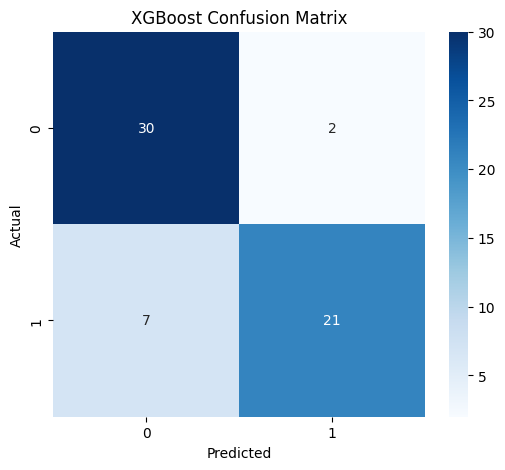


LIGHTGBM RESULTS
Accuracy : 0.85
Precision: 0.8585193889541716
Recall   : 0.85
F1 Score : 0.8480818414322251

LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.94      0.87        32
           1       0.91      0.75      0.82        28

    accuracy                           0.85        60
   macro avg       0.86      0.84      0.85        60
weighted avg       0.86      0.85      0.85        60



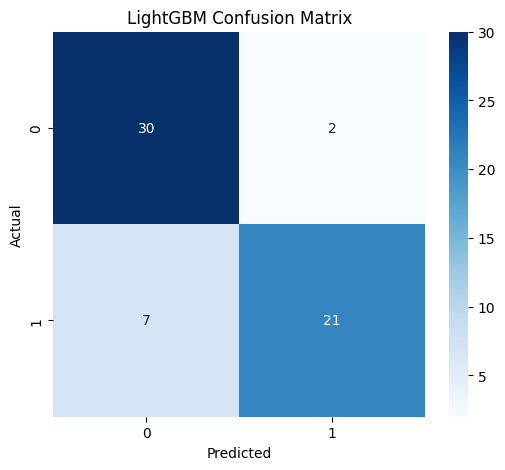


MODEL COMPARISON
      Model  Accuracy  Precision  Recall  F1 Score
0   XGBoost      0.85   0.858519    0.85  0.848082
1  LightGBM      0.85   0.858519    0.85  0.848082

XGBoost Feature Importance:
     Feature  Importance
2         cp    0.249768
12      thal    0.124694
11        ca    0.110580
9    oldpeak    0.093233
8      exang    0.077377
1        sex    0.055180
0        age    0.052081
7    thalach    0.050471
5        fbs    0.042250
4       chol    0.037997
3   trestbps    0.037488
10     slope    0.036021
6    restecg    0.032861


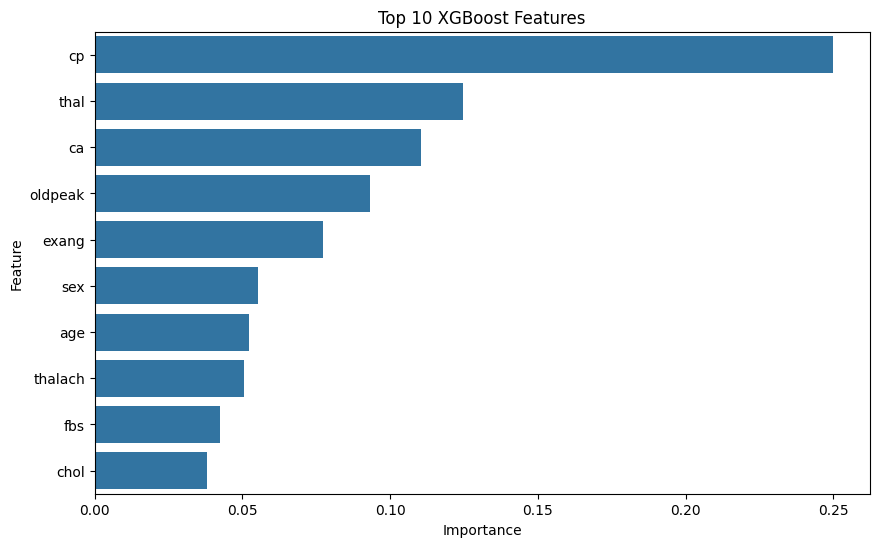


LightGBM Feature Importance:
     Feature  Importance
4       chol         106
0        age         100
7    thalach          94
9    oldpeak          68
3   trestbps          65
2         cp          55
12      thal          51
11        ca          48
1        sex          24
6    restecg          23
10     slope          18
8      exang          13
5        fbs           8


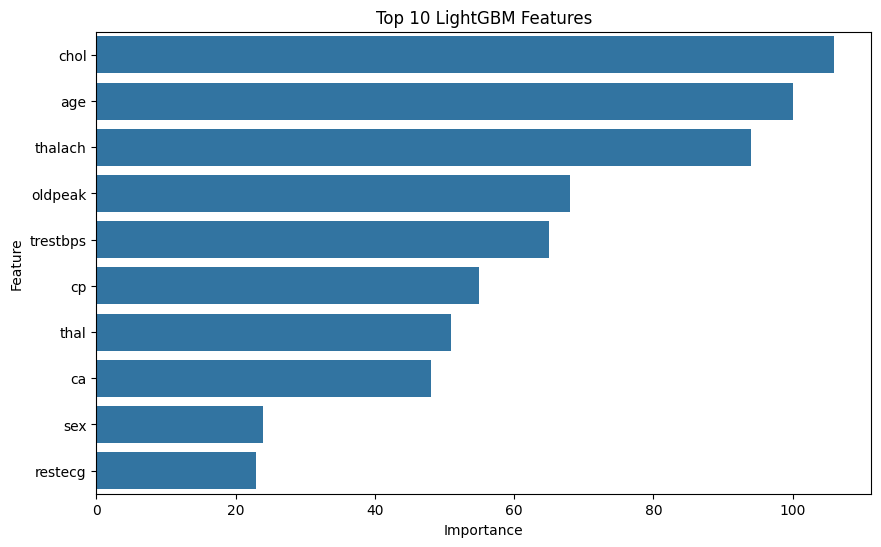


Calculating SHAP values...


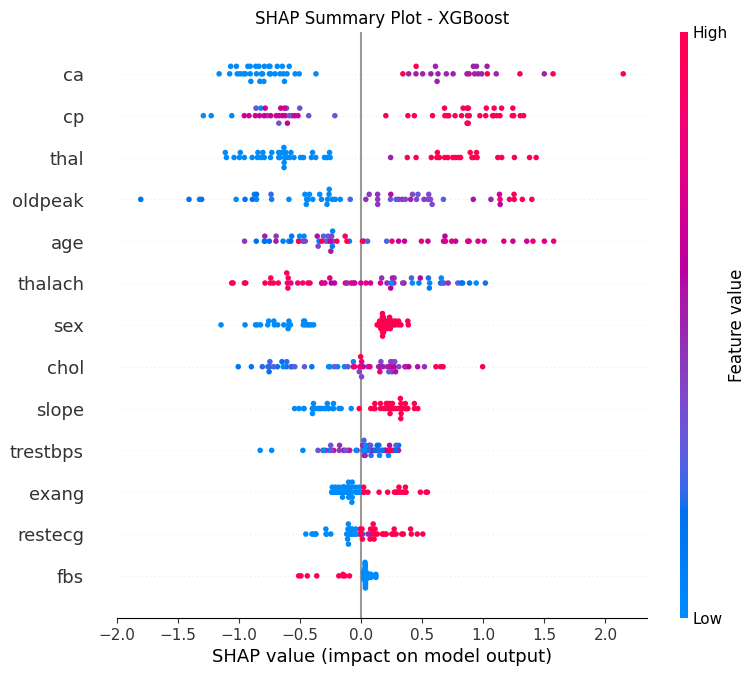

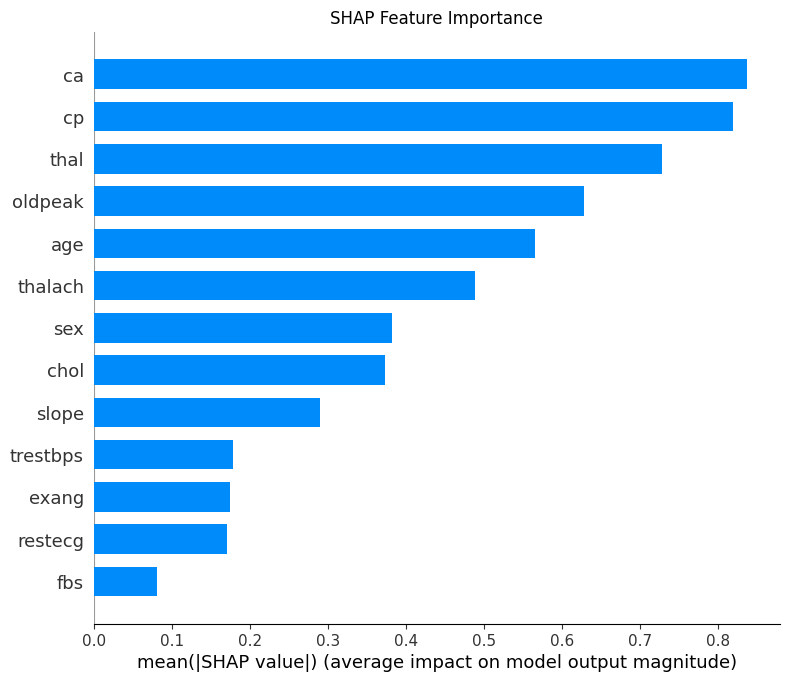


PROGRAM COMPLETED SUCCESSFULLY

Saved files:
1. heart_disease_xgb_lightgbm_predictions.csv
2. heart_disease_boosting_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================================
# PROGRAM 10: HEART DISEASE
# XGBOOST, LIGHTGBM AND SHAP INTERPRETABILITY
# ============================================================

# ============================================================
# 1. Install required libraries
# ============================================================

!pip install xgboost lightgbm shap -q

# ============================================================
# 2. Import libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

# ============================================================
# 3. Upload CSV
# ============================================================

print("Choose Heart Disease CSV file:")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

# ============================================================
# 4. Display dataset
# ============================================================

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

# ============================================================
# 5. Clean column names
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print("\nCleaned Columns:")
print(df.columns.tolist())

# ============================================================
# 6. Dataset information
# ============================================================

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================================
# 7. Handle missing values
# ============================================================

for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(
        df[col].median()
    )

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

# ============================================================
# 8. Remove duplicates
# ============================================================

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df = df.drop_duplicates()

# ============================================================
# 9. Identify target
# ============================================================

if "condition" in df.columns:
    target = "condition"

elif "target" in df.columns:
    target = "target"

else:
    target = df.columns[-1]

print("\nTarget Column:", target)

# ============================================================
# 10. Separate Features and Target
# ============================================================

X = df.drop(
    target,
    axis=1
)

y = df[target]

# ============================================================
# 11. Encode categorical features
# ============================================================

X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

# ============================================================
# 12. Convert target to 0 and 1 if required
# ============================================================

if y.dtype == "object":

    unique_values = y.unique()

    mapping = {
        value: index
        for index, value in enumerate(unique_values)
    }

    y = y.map(mapping)

# Convert to integer
y = y.astype(int)

print("\nTarget Values:")
print(y.value_counts())

# ============================================================
# 13. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:")
print(X_train.shape)

print("\nTesting Shape:")
print(X_test.shape)

# ============================================================
# 14. XGBOOST MODEL
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

# Train XGBoost
xgb_model.fit(
    X_train,
    y_train
)

# Prediction
xgb_pred = xgb_model.predict(
    X_test
)

# ============================================================
# 15. XGBoost Evaluation
# ============================================================

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred,
    average="weighted"
)

xgb_recall = recall_score(
    y_test,
    xgb_pred,
    average="weighted"
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    average="weighted"
)

print("\n======================================")
print("XGBOOST RESULTS")
print("======================================")

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

# ============================================================
# 16. XGBoost Classification Report
# ============================================================

print("\nXGBoost Classification Report:")

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

# ============================================================
# 17. XGBoost Confusion Matrix
# ============================================================

cm_xgb = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

# ============================================================
# 18. LIGHTGBM MODEL
# ============================================================

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    verbosity=-1
)

# Train LightGBM
lgb_model.fit(
    X_train,
    y_train
)

# Prediction
lgb_pred = lgb_model.predict(
    X_test
)

# ============================================================
# 19. LightGBM Evaluation
# ============================================================

lgb_accuracy = accuracy_score(
    y_test,
    lgb_pred
)

lgb_precision = precision_score(
    y_test,
    lgb_pred,
    average="weighted"
)

lgb_recall = recall_score(
    y_test,
    lgb_pred,
    average="weighted"
)

lgb_f1 = f1_score(
    y_test,
    lgb_pred,
    average="weighted"
)

print("\n======================================")
print("LIGHTGBM RESULTS")
print("======================================")

print("Accuracy :", lgb_accuracy)
print("Precision:", lgb_precision)
print("Recall   :", lgb_recall)
print("F1 Score :", lgb_f1)

# ============================================================
# 20. LightGBM Classification Report
# ============================================================

print("\nLightGBM Classification Report:")

print(
    classification_report(
        y_test,
        lgb_pred
    )
)

# ============================================================
# 21. LightGBM Confusion Matrix
# ============================================================

cm_lgb = confusion_matrix(
    y_test,
    lgb_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lgb,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM Confusion Matrix")

plt.show()

# ============================================================
# 22. Compare XGBoost and LightGBM
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "XGBoost",
        "LightGBM"
    ],

    "Accuracy": [
        xgb_accuracy,
        lgb_accuracy
    ],

    "Precision": [
        xgb_precision,
        lgb_precision
    ],

    "Recall": [
        xgb_recall,
        lgb_recall
    ],

    "F1 Score": [
        xgb_f1,
        lgb_f1
    ]
})

print("\n======================================")
print("MODEL COMPARISON")
print("======================================")

print(comparison)

# ============================================================
# 23. Feature Importance - XGBoost
# ============================================================

xgb_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb_model.feature_importances_

})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nXGBoost Feature Importance:")
print(xgb_importance)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=xgb_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 XGBoost Features")

plt.show()

# ============================================================
# 24. Feature Importance - LightGBM
# ============================================================

lgb_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": lgb_model.feature_importances_

})

lgb_importance = lgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nLightGBM Feature Importance:")
print(lgb_importance)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=lgb_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 LightGBM Features")

plt.show()

# ============================================================
# 25. SHAP INTERPRETABILITY - XGBoost
# ============================================================

print("\nCalculating SHAP values...")

explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(
    X_test
)

# ============================================================
# 26. SHAP Summary Plot
# ============================================================

plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title(
    "SHAP Summary Plot - XGBoost"
)

plt.show()

# ============================================================
# 27. SHAP Bar Plot
# ============================================================

plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title(
    "SHAP Feature Importance"
)

plt.show()

# ============================================================
# 28. Save Predictions
# ============================================================

result = X_test.copy()

result["Actual"] = y_test.values

result["XGBoost_Predicted"] = xgb_pred

result["LightGBM_Predicted"] = lgb_pred

result.to_csv(
    "heart_disease_xgb_lightgbm_predictions.csv",
    index=False
)

# ============================================================
# 29. Save Cleaned Dataset
# ============================================================

df.to_csv(
    "heart_disease_boosting_cleaned.csv",
    index=False
)

print("\n======================================")
print("PROGRAM COMPLETED SUCCESSFULLY")
print("======================================")

print("\nSaved files:")
print("1. heart_disease_xgb_lightgbm_predictions.csv")
print("2. heart_disease_boosting_cleaned.csv")

# Download predictions
files.download(
    "heart_disease_xgb_lightgbm_predictions.csv"
)